In [38]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [39]:
# 1. LOAD DATASET
#  For MNIST (digits)
# train = pd.read_csv("mnist_train.csv")
# test = pd.read_csv("mnist_test.csv")

# For EMNIST (alphabets)
train = pd.read_csv("emnist-balanced-train.csv")
test = pd.read_csv("emnist-balanced-test.csv")


In [40]:
# 2. PREPROCESS
X_train = train.iloc[:,1:] / 255.0
y_train = train.iloc[:,0]

X_test = test.iloc[:,1:] / 255.0
y_test = test.iloc[:,0]

In [41]:
# reshape
X_train = X_train.values.reshape(-1,28,28,1)
X_test = X_test.values.reshape(-1,28,28,1)

In [42]:

# Fix EMNIST rotation (IMPORTANT)
X_train = np.transpose(X_train, (0,2,1,3))
X_test = np.transpose(X_test, (0,2,1,3))

In [43]:
# number of classes
num_classes = len(np.unique(y_train))

In [44]:
# one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)


In [45]:
# 3. BUILD CNN MODEL

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
# 4. COMPILE
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [47]:
# 5. TRAIN
model.fit(X_train, y_train, epochs=5, batch_size=256)

Epoch 1/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7181 - loss: 0.9519
Epoch 2/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8362 - loss: 0.4971
Epoch 3/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8566 - loss: 0.4240
Epoch 4/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8662 - loss: 0.3832
Epoch 5/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8747 - loss: 0.3544


In [48]:
# 6. EVALUATE

loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8645 - loss: 0.4052
Accuracy: 0.8645140528678894


In [49]:
# 7. PREDICT
pred = model.predict(X_test[0].reshape(1,28,28,1))
pred_class = np.argmax(pred)

print("Predicted class:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
Predicted class: 39


In [50]:
letter = chr(pred_class + ord('A'))
print("Predicted Letter:", letter)

Predicted Letter: h


In [51]:
# Convert one-hot → labels
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [52]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

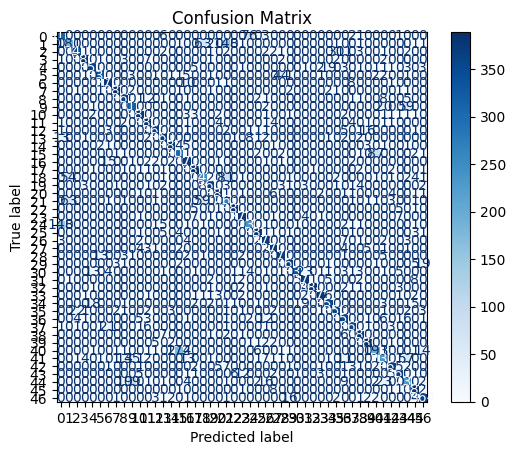

In [53]:
# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [54]:
# Pick any index
index = 5


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

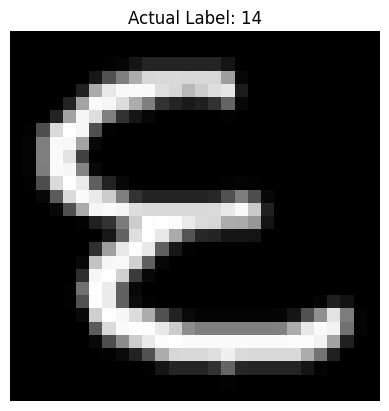

In [55]:
# Show image
plt.imshow(X_test[index].reshape(28,28), cmap='gray')
plt.title("Actual Label: " + str(np.argmax(y_test[index])))
plt.axis('off')


In [56]:
# Prediction
pred = model.predict(X_test[index].reshape(1,28,28,1))
pred_class = np.argmax(pred)

print("Predicted:", pred_class)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted: 14


In [57]:
letter = chr(pred_class + ord('A'))
actual_letter = chr(np.argmax(y_test[index]) + ord('A'))

print("Actual:", actual_letter)
print("Predicted:", letter)

Actual: O
Predicted: O
